### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.style.use('dark_background')
sns.set_palette('husl')

#paths
RAW_PATH       = '../data/raw/btc_5m.csv'
PROCESSED_DIR  = '../data/processed'
PROCESSED_PATH = '../data/processed/btc_5m_clean.csv'

### Load Data

In [2]:
df = pd.read_csv(RAW_PATH, 
                 index_col = 0,  # open_time is the index
                 parse_dates = True  # convert index string -> datetime
                )
print("Raw data loaded successfully!")
print(f'  Shape   : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'  From    : {df.index.min()}')
print(f'  To      : {df.index.max()}')
print(f'  Columns : {list(df.columns)}')
df.head()

Raw data loaded successfully!
  Shape   : 49,951 rows x 9 columns
  From    : 2025-09-16 03:00:00+00:00
  To      : 2026-03-08 13:30:00+00:00
  Columns : ['open', 'high', 'low', 'close', 'volume', 'quote_asset_volume', 'num_trades', 'taker_buy_base', 'taker_buy_quote']


,open,high,low,close,volume,quote_asset_volume,num_trades,taker_buy_base,taker_buy_quote
open_time,,,,,,,,,
2025-09-16 03:00:00+00:00,115034.48,115149.43,115034.44,115143.83,16.55927,1906008.682,5527,10.84775,1.248542e+06
2025-09-16 03:05:00+00:00,115143.84,115179.77,115082.14,115082.15,11.61962,1337826.988,4682,3.87515,4.461520e+05
2025-09-16 03:10:00+00:00,115082.15,115119.36,115082.14,115114.00,9.62778,1108186.407,2832,5.04930,5.811822e+05
2025-09-16 03:15:00+00:00,115114.00,115180.00,115113.99,115124.42,25.91002,2983779.987,2518,10.47316,1.206003e+06
2025-09-16 03:20:00+00:00,115124.42,115155.93,115099.95,115130.60,12.41981,1429966.468,3116,5.15631,5.936324e+05


### Data Types Inspection

In [3]:
print('Columns Datatypes: ')
print(df.dtypes)
print(f'Index dtype : {df.index.dtype}')

Columns Datatypes: 
open                  float64
high                  float64
low                   float64
close                 float64
volume                float64
quote_asset_volume    float64
num_trades              int64
taker_buy_base        float64
taker_buy_quote       float64
dtype: object
Index dtype : datetime64[us, UTC]


### Basic Statistics

In [4]:
df[['open', 'high', 'low', 'close', 'volume']].describe().round(2)

,open,high,low,close,volume
count,49951.00,49951.00,49951.00,49951.00,49951.00
mean,93122.49,93202.32,93041.48,93121.52,74.18
std,16198.52,16195.40,16200.77,16198.64,117.82
min,60076.81,61060.22,60000.00,60081.74,1.17
25%,86547.86,86650.00,86450.00,86547.54,22.82
50%,90920.00,90985.67,90852.20,90919.81,42.46
75%,108437.69,108548.81,108336.11,108435.62,82.08
max,126011.18,126199.63,125868.13,126011.18,5120.93


In [5]:
df.isnull().sum() # checking Missing values

open                  0
high                  0
low                   0
close                 0
volume                0
quote_asset_volume    0
num_trades            0
taker_buy_base        0
taker_buy_quote       0
dtype: int64

In [6]:
n_duplicates = df.index.duplicated().sum()
print(f'Duplicate timestamps: {n_duplicates}')

if n_duplicates > 0:
    print('Sample duplicates:')
    print(df[df.index.duplicated(keep=False)].head(6))
else:
    print('✅ All timestamps are unique!')

Duplicate timestamps: 0
✅ All timestamps are unique!


### Visualize BTC Price History

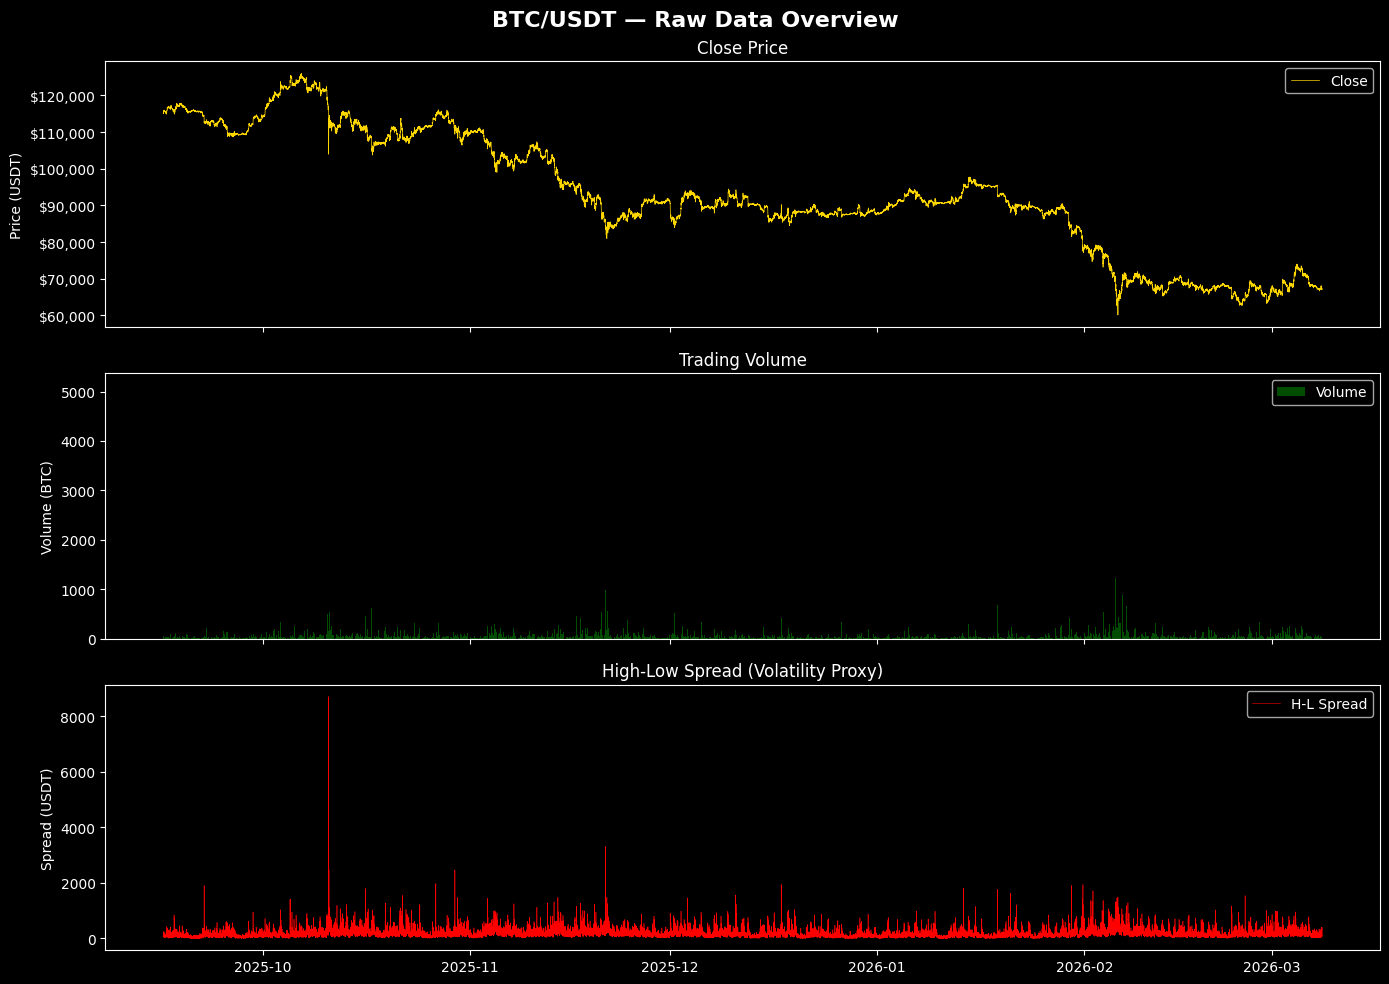

In [7]:
fig, axes = plt.subplots(3, 1, figsize = (14, 10), sharex = True)
fig.suptitle('BTC/USDT — Raw Data Overview', fontsize=16, fontweight='bold')

# Plot 1 Close Price
axes[0].plot(df.index, df['close'], color='gold', linewidth=0.5, label='Close')
axes[0].set_ylabel('Price (USDT)')
axes[0].set_title('Close Price')
axes[0].legend()
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_ : f'${x:,.0f}'))

# plot 2 Volume
axes[1].bar(df.index, df['volume'], color='green', alpha=0.6, width=0.003, label='Volume')
axes[1].set_ylabel('Volume (BTC)')
axes[1].set_title('Trading Volume')
axes[1].legend()

#plot 3 High-low Spread
spread = df['high'] - df['low']
axes[2].plot(df.index, spread, color='red', linewidth=0.4, label='H-L Spread')
axes[2].set_ylabel('Spread (USDT)')
axes[2].set_title('High-Low Spread (Volatility Proxy)')
axes[2].legend()

plt.tight_layout()
plt.show()

### Distribution of Returns

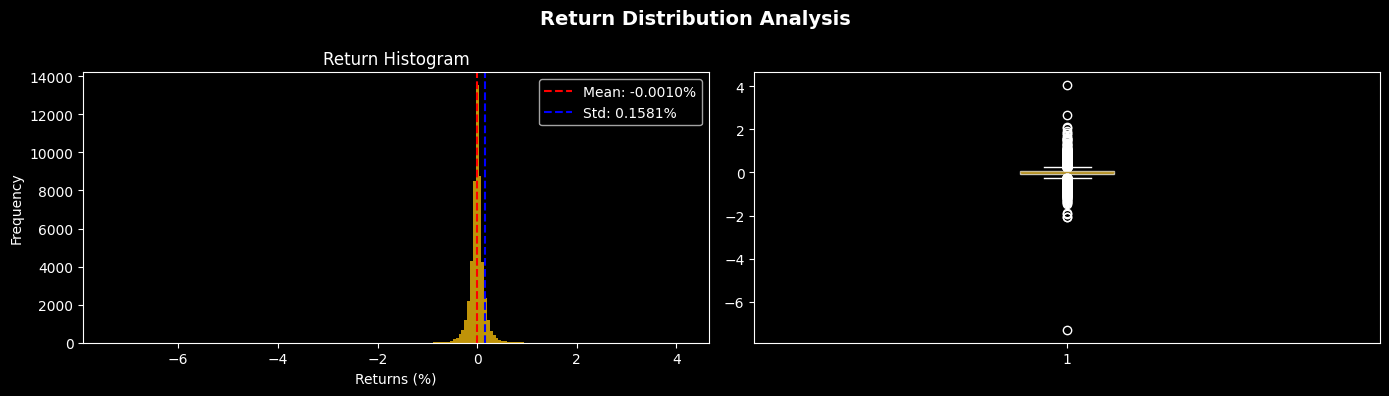

Return statistics:
  Mean   : -0.00096%
  Std    : 0.15809%
  Min    : -7.3382%
  Max    : 4.0816%
  Extreme outliers (>3% move in 5 min): 2


In [8]:
# Percentage return per candle
returns = df['close'].pct_change().dropna()*100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Return Distribution Analysis', fontsize=14, fontweight='bold')

axes[0].hist(returns, bins=200, color='#F0B90B', alpha=0.8, edgecolor='none')
axes[0].axvline(returns.mean(), color='red', linestyle='--', label=f'Mean: {returns.mean():.4f}%')
axes[0].axvline(returns.std(), color='blue', linestyle='--', label=f'Std: {returns.std():.4f}%')
axes[0].set_xlabel('Returns (%)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Return Histogram')
axes[0].legend()

axes[1].boxplot(returns, vert=True, patch_artist=True, boxprops=dict(facecolor='#F0B90B', alpha=0.7))

plt.tight_layout()
plt.show()

print(f'Return statistics:')
print(f'  Mean   : {returns.mean():.5f}%')
print(f'  Std    : {returns.std():.5f}%')
print(f'  Min    : {returns.min():.4f}%')
print(f'  Max    : {returns.max():.4f}%')
print(f'  Extreme outliers (>3% move in 5 min): {(returns.abs() > 3).sum()}')

- We compute percentage returns (how much price changed candle-to-candle).
- A healthy return distribution should be bell-shaped (close to normal).
- Extreme outliers (fat tails) indicate data anomalies or major market even

### Anomaly Detection
We check for physically impossible values:
- `close <= 0` → price can never be `zero` or `negative`
- `volume < 0` → volume can never be negative
- `high < low` → high must always be >= low
- `high < close` or `low > close` → close must be within high-low range

In [9]:
anomalies = {}
# Rule 1: prices must be positive
anomalies['zero_or_neg_close'] = (df['close'] <= 0).sum()
anomalies['zero_or_neg_open'] = (df['open'] <= 0).sum()
anomalies['zero_or_neg_high'] = (df['high'] <= 0).sum()
anomalies['zero_or_neg_low'] = (df['low'] <= 0).sum()

# Rule 2: volume must be non-negative
anomalies['negative_volume'] = (df['volume'] <= 0).sum()

# Rule 3: OHLC consistency
anomalies['high_it_low'] = (df['low'] > df['high']).sum()
anomalies['close_above_high'] = (df['close'] > df['high']).sum()
anomalies['close_below_low'] = (df['close'] < df['low']).sum()

# Rule 4: extreme price spikes (>20% move in a single 5-min candle)
ret = df['close'].pct_change().sum()

print('Anomaly Report')
total_anomalies = 0
for rule,count in anomalies.items():
    status = '✅' if count == 0 else '⚠️ '
    print(f'  {status}  {rule:<25} : {count}')
    total_anomalies += count
print(f'Total Anomalies: {total_anomalies}')

Anomaly Report
  ✅  zero_or_neg_close         : 0
  ✅  zero_or_neg_open          : 0
  ✅  zero_or_neg_high          : 0
  ✅  zero_or_neg_low           : 0
  ✅  negative_volume           : 0
  ✅  high_it_low               : 0
  ✅  close_above_high          : 0
  ✅  close_below_low           : 0
Total Anomalies: 0


### Creating Target Columns

We create two targets:

- `next_close` → the actual price of the NEXT candle (regression target)
- `direction` → 1 if price went UP, 0 if DOWN (classification target)

In [10]:
# next_close: shift close price up by 1 row
# Row N's next_close = Row N+1's close
df['next_close'] = df['close'].shift(-1)

# Drop last row (it has no 'next' candle, so next_close is NaN)
df.dropna(subset=['next_close'],inplace=True)

df['direction'] = (df['next_close'] > df['close']).astype(int)

print('Target columns created!')
print()
print('Sample (last 5 rows):')
print(df[['close', 'next_close', 'direction']].tail(5).to_string())


Target columns created!

Sample (last 5 rows):
                              close  next_close  direction
open_time                                                 
2026-03-08 13:05:00+00:00  67295.23    66974.10          0
2026-03-08 13:10:00+00:00  66974.10    67075.18          1
2026-03-08 13:15:00+00:00  67075.18    67014.18          0
2026-03-08 13:20:00+00:00  67014.18    67163.88          1
2026-03-08 13:25:00+00:00  67163.88    67088.01          0


In [11]:
up_pct = df['direction'].mean()*100
down_pct = 100 - up_pct
print(f'Direction class balance:')
print(f'Up (1) : {up_pct:.2f}')
print(f'Down (0) : {down_pct:.2f}')
print('Dataset is balanced')

Direction class balance:
Up (1) : 49.71
Down (0) : 50.29
Dataset is balanced


### Save Cleaned Data

In [14]:
import os
os.makedirs(PROCESSED_DIR, exist_ok=True)
df.to_csv(PROCESSED_PATH)

size_kb = os.path.getsize(PROCESSED_PATH) / 1024
print(f'✅ Cleaned data saved!')
print(f'   Path      : {PROCESSED_PATH}')
print(f'   Rows      : {len(df):,}')
print(f'   Columns   : {list(df.columns)}')
print(f'   File size : {size_kb:.1f} KB')
print(f'   Date range: {df.index.min()} → {df.index.max()}')
print()


✅ Cleaned data saved!
   Path      : ../data/processed/btc_5m_clean.csv
   Rows      : 49,950
   Columns   : ['open', 'high', 'low', 'close', 'volume', 'quote_asset_volume', 'num_trades', 'taker_buy_base', 'taker_buy_quote', 'next_close', 'direction']
   File size : 5944.3 KB
   Date range: 2025-09-16 03:00:00+00:00 → 2026-03-08 13:25:00+00:00

